In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# TOC:
* [The Nearest Class Centroid (NCC) classifier](#the-nearest-class-centroid-ncc-classifier)
* [K Nearest Neighbor](#K-Nearest-Neighbor)
* [Fisher's Discriminant Analysis](#fishers-discriminant-analysis)
  * [plot](#plot)
* [Neural Networks](#neural-networks)
  * [Forward Propagation](#forward-propagation)
  * [Cross Entropy Error](#cross-entropy-error)
  * [Sum Of Squares Error](#sum-of-squares-error)
  * [Backward Propagation](#backward-propagation)
* [Gaussian Mixture Model](#gaussian-mixture-model)
  * [Expectation Maximization](#posterior-probability)
  * [Decision Boundary Plot](#decision-boundary-plot)
* [Linear Regression](#linear-regression)
  * [Normal Equation](#normal-equation)
  * [Plot Model](#plot-model)

# The Nearest Class Centroid (NCC) classifier
$$
% Tags for search:
% nearest-centroid-based classification algorithm
% centroid class
$$

In [ ]:
X = np.array([  [1, 1, 0, -2],
                [2, 0, -1, -1]])
t = np.array([1, 1, 2, 2])
test_x = np.array([ [2, 0, -1, -2],
                    [0, 0, 1, 0]])

centroids = np.hstack(( np.mean(X[:, t == 1], axis=1)[:, np.newaxis],
                        np.mean(X[:, t == 2], axis=1)[:, np.newaxis]))

def dist(a, b):
    return np.linalg.norm(a - b)

for x in test_x.T:
    xvec = x[:,np.newaxis]
    if dist(centroids[:, 0], xvec) <= dist(centroids[:, 1], xvec):
        print(f"{xvec} is classified as 1\n")
    else:
        print(f"{xvec} is classified as 2\n")

# K Nearest Neighbor
$$
% Tags for search:
% K-nearest
% KNN
$$

In [ ]:
X = np.array([  [2, 3, 4, 6, 7, 8],
                [3, 4, 2, 6, 5, 7]])
T = np.array([  [5, 6],
                [4, 4.5]])
t = np.array([0, 0, 0, 1, 1, 1])

def dist(a, b):
    return np.linalg.norm(a - b)

for xt in T.T:
    xtvec = xt[:,np.newaxis]
    dist_list = []
    for xn in X.T:
        xnvec = xn[:,np.newaxis]
        dist_list.append(dist(xtvec, xnvec))
    xtlabel = t[np.argmin(dist_list)]
    print(f"{xtvec} is classified as C_{xtlabel+1}\n")


# Fisher's Discriminant Analysis
$$
% Tags for search:
% LDA
% FDA
% Linear Discriminant Analysis
% Fisher Discriminant Analysis
% Fishers Linear Discriminant
$$

In [ ]:
# expects data on the form (if data is not on this form do X.T in function input)
X = np.array([  [ 1,  2],
                [ 4,  6],
                [ 8,  3],
                [ 3, -1],
                [-1, -5],
                [-8, -9]])
t = np.array([0, 0, 1, 1, 2, 2]) # uses classes as index so keep that in mind if it isnt 0 indexed

In [ ]:
def class_means(X, t):
    classes = np.unique(t)
    ms = list(np.zeros(len(classes)))
    Ns = list(np.zeros(len(classes)))
    N = len(X)
    for n in range(N):
        Ns[t[n]] += 1
        ms[t[n]] += X[n]
    
    return_array = []
    for m, n in zip(ms, Ns):
        return_array.append(m/n)
    return return_array

def LDA_scatter_matrix(X, t):
    m = X.mean(axis=0)
    means = class_means(X, t)
    # for i, mean in enumerate(means):
    #     print(f"Mean for class {i+1}:\n", mean)

    K = len(means)
    N = len(X)

    # https://stackoverflow.com/questions/28663856/how-do-i-count-the-occurrence-of-a-certain-item-in-an-ndarray
    unique, counts = np.unique(t, return_counts=True)
    Ns = dict(zip(unique, counts))
    
    S_W = 0
    S_B = 0
    for k in range(K):
        S_B += Ns[k] * np.outer(means[k] - m, means[k] - m)
        
        for n in range(N):
            if t[n] == k:
                S_W += (X[n] - means[k])[:, np.newaxis] @ (X[n] - means[k])[:, np.newaxis].T
    
    return S_B, S_W

def projection_matrix(X, t, D_prime=1):
    S_B, S_W = LDA_scatter_matrix(X, t)
    # print("S_B:\n", S_B)
    # print("S_W:\n", S_W)
    eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
    sorted_indices = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, sorted_indices]
    W = eigvecs[:, :D_prime]
    return W

In [ ]:
w = projection_matrix(X, t)
print(f"w = \n{w}")

## Plot

In [ ]:
def plot_lda(X, t, w, colors=['b', 'r', 'g'], markers=['o', 's', '^']):
    plt.title("LDA Projection")
    plt.axis('equal')
    plt.grid()
    
    labels = np.unique(t)
    for i, label in enumerate(labels):
        plt.scatter(*X[t == label].T, label=f'Class {label}', color=colors[i], marker=markers[i])
    n = np.linspace(np.min(X[:,0])/w[0], np.max(X[:,0])/w[0], 100)
    plt.plot(n*w[0], n*w[1], label='Projection line')

    plt.legend()

In [ ]:
plot_lda(X, t, w)

# Probabilistic Generative Classification Model

The following equations are used to calculate the model parameters:
$$
% equation 2.255
P(C_k) = \frac{N_k}{N}
$$
$$
% slide 339
\mu_k = \frac{1}{N_k} \sum_{n \in C_k} x_n
$$
$$
% slide 339
\Sigma = \sum_{k} \frac{N_k}{N} S_k
$$
$$
% slide 339
S_k = \frac{1}{N_k} \sum_{n \in C_k} (x_n - \mu_k)(x_n - \mu_k)^T
$$



In [ ]:
def PGM_MLE_mean(x, l, ns, C):
    K = len(C)
    mus = []
    for k in range(K):
        mu = 1/ns[k] * np.sum(x[:,l==C[k]], axis=1)[:, np.newaxis]
        mus.append(mu)
    return mus

def PGM_MLE_covariance(x, l, ns, C, mus, N):
    K = len(C)
    Ss = []
    for k in range(K):
        S = 1/ns * ((x[:,l==C[k]] - mus[k]) @ (x[:,l==C[k]] - mus[k]).T)
        Ss.append(S)
    
    sigma = 0
    for n, S in zip(ns, Ss):
        sigma += n/N * S

    return sigma

def PGM_MLE_probability(N, ns):
    Ps = []
    for n in ns:
        Ps.append(n/N)
    return Ps

def PGM_MLE_parameters(data, labels):
    classes, ns = np.unique(labels, return_counts=True)
    N = len(data.T)

    mus = PGM_MLE_mean(data, labels, ns, classes)
    sigma = PGM_MLE_covariance(data, labels, ns, classes, mus, N)
    probs = PGM_MLE_probability(N, ns)

    return mus, sigma, probs

In [ ]:
X = np.array([  [2, 4, 4, 6, 7, 7],
                [3, 5, 3, 6, 7, 5]])
T = np.array([  [5],
                [4.5]])
l = np.array([0, 0, 0, 1, 1, 1])
label_names = {
    0: 2,
    1: 1
}

mus, sigma, probs = PGM_MLE_parameters(X, l)

for i, mu in enumerate(mus):
    print(f"mu_{i} =\n{mu}\n")

print(f"sigma =\n{sigma}\n")

for i, p in enumerate(probs):
    print(f"p(c_{label_names[i]}) = {p}\n")

## Posterior Probability
$$
% partial derivative
$$

The posterior probability is computed using the following derivative of Bayes theorem:
$$
% equation (4.69)
w_k = \Sigma^{-1} \mu_k
$$
$$
% equation (4.70)
w_{k0} = -\frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \ln \left( p(C_k) \right)
$$
$$
% equation (4.68)
a_k(x) = w_k^T x + w_{k0}
$$
$$
% equation (4.62)
p(C_k|x) = \frac{\exp(a_k(x))}{\sum_j \exp(a_j(x))}
$$


In [ ]:
def w(mus, cov):
    ws = []
    for mu in mus:
        ws.append(np.linalg.inv(cov) @ mu)
    return ws

def w_0(mus, cov, ps):
    w_0s = []
    for mu, p in zip(mus, ps):
        w_0s.append(- 1/2 * mu.T @ np.linalg.inv(cov) @ mu + np.log(p))
    return w_0s

def A(ws, w_0s, x):
    As = []
    for w, w_0 in zip(ws, w_0s):
        As.append(w.T @ x + w_0)
    return As

def probability_given_x(As):
    probs = []
    for a in As:
        probs.append(np.exp(a) / np.sum(np.exp(As)))
    return probs

In [ ]:
ws = w(mus, sigma)
w_0s = w_0(mus, sigma, probs)
As = A(ws, w_0s, T)
probs_x = probability_given_x(As)
p0 = probs_x[0].item()

## Plot Decision Boundary

In [ ]:
def plot_scatter(data, target, n_class=2, padding=1):
    x_min = np.min(data[0]) - padding
    x_max = np.max(data[0]) + padding
    y_min = np.min(data[1]) - padding
    y_max = np.max(data[1]) + padding
    
    plt.scatter(*data, c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar()
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

def plot_decision_boundary(data, ws, w0, padding=1):
    x_min = np.min(data[0]) - padding
    x_max = np.max(data[0]) + padding
    y_min = np.min(data[1]) - padding
    y_max = np.max(data[1]) + padding

    x1=np.linspace(x_min, x_max, 100)
    w1, w2 = ws
    w01, w02 = w0

    # Difference vector
    wd = w1 - w2
    w0d = w01 - w02
    # Boundary: wd[0]*x + wd[1]*y + w0d = 0, solve for y
    a = -wd[0,0] / wd[1,0]
    b = -w0d[0,0] / wd[1,0]
    x2= a * x1 + b

    y_fill_top=np.full(x1.shape,y_max)
    y_fill_bottom=np.full(x1.shape,y_min)
    plt.fill_between(x1,y_fill_top,x2,color='C0',alpha=0.3)
    plt.fill_between(x1,x2,y_fill_bottom,color='C1',alpha=0.3)
    plt.plot(x1,x2,'k--',label='Decision Boundary')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.title('Decision Boundary with Least Squares')
    plt.legend()

In [ ]:
plot_scatter(X, l)
plot_decision_boundary(X, ws, w_0s)

# Neural Networks

https://alexlenail.me/NN-SVG/

## Forward Propagation

The neuron transformations and thereby forward propagation is calculated using the following equations:
$$
a = w^{T}x + w_{0}
$$
$$
z = h(a)
$$

In [11]:
W_1 = np.array([[0.2, -0.8, 0.6],
                [0.7, -1.0, 0.3],
                [-0.5, -0.3, -0.4]])
W_2 = np.array([[0.7],
                [0.2],
                [-0.1],
                [-0.4]])
weigths = [W_1, W_2]

x = np.array([[0.6, -0.3]]).T

# slide 450
def neuron_transformation(x, W, h):
    xbias = np.vstack(([1.0], x))
    a = W.T @ xbias
    print("a =\n", a)
    z = h(a)
    print("z =\n", z)
    return a, z

# slide 452
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

def identity(a):
    return a

def forward(x, weigths, h, h_output=None):
    activations = []
    outputs = []
    z = x
    num_layers = len(weigths)

    for i, W in enumerate(weigths):
        if i == num_layers-1 and h_output:
            h = h_output
        print(f"-- Layer {i+1} calculation steps --")
        a, z = neuron_transformation(z, W, h)
        activations.append(a)
        outputs.append(z)
        print()
    return outputs[-1], activations, outputs

y1, activations, outputs = forward(x, weigths, sigmoid, identity)
print("y =", y1.item())

-- Layer 1 calculation steps --
a =
 [[ 0.77]
 [-1.31]
 [ 0.9 ]]
z =
 [[0.68352089]
 [0.21248684]
 [0.7109495 ]]

-- Layer 2 calculation steps --
a =
 [[0.53107569]]
z =
 [[0.53107569]]

y = 0.5310756932850076


## Cross Entropy Error
$$
% cross-entropy-error
$$

The generel equation for cross entropy error is:
$$
E(t, y) = -\sum^{N}_{n=1} (t_{n} \ln(y_{n}) + (1 - t_{n}) \ln(1 - y_{n}))
$$

The values for $t_1$ and $y_1$ can be inserted into this to get $E(t_1, y_1)$.

In [12]:
# slide 344
def cross_entropy_error(t, y):
    N = len(y)
    E = 0
    for n in range(N):
        E -= t[n] * np.log(y[n]) + (1 - t[n]) * np.log(1 - y[n])
    return E[0]

t1 = np.array([[1]])
print("The value will be E(t_1, y_1) =", cross_entropy_error(t1, y1))

The value will be E(t_1, y_1) = 0.6328507193399423


## Sum Of Squares Error
$$
% sum-of-squares-error
$$

The generel equation for the sum of squares error is is:
$$
E(t, y) = \frac{1}{2} \sum^{N}_{n=1} \{ y(x_n, w) - t_n \}^2
$$

The values for $t_1$ and $y_1$ can be inserted into this to get $E(t_1, y_1)$.

In [2]:
# equation (5.14) page 251

def sum_of_squares_error(t, y):
    return 1/2 * np.sum(y - t)**2

t1 = np.array([[-0.5]])
print("The sum of squares error is E[t_1, y_1] =", sum_of_squares_error(t1, y1))

NameError: name 'np' is not defined

## Backward Propagation
$$
% Gradients
% back-propagation
% descent
% optimize
$$

In [1]:
# slide 452
def sigmoid_derivative(a):
    z = sigmoid(a)
    return z * (1 - z)

def compute_all_gradients(x, t, weights, activations, outputs, y, h_derivative):
    num_layers = len(weights)
    gradients = [None] * num_layers
    deltas = [None] * num_layers

    deltas[-1] = y - t
    print(f"δ^({num_layers}) =\n", deltas[-1], "\n")
    

    for k in range(num_layers - 2, -1, -1):
        W_no_bias = weights[k + 1][1:, :]
        deltas[k] = (W_no_bias @ deltas[k + 1]) * h_derivative(activations[k])
        print(f"δ^({k+1}) =\n", deltas[k], "\n")
    for k in range(num_layers):
        if k == 0:
            z_prev = np.vstack(([1.0], x))
        else:
            z_prev = np.vstack(([1.0], outputs[k - 1]))

        gradients[k] = z_prev @ deltas[k].T
        print(f"∂E/∂W^({k+1}) =\n", gradients[k], "\n")
    return gradients, deltas

gradients, deltas = compute_all_gradients(x, t1, weigths, activations, outputs, y1, sigmoid_derivative)

print(f"\n∂E/∂a_2,1 = {deltas[1][0].item()}")
print(f"∂E/∂w^(2)_2,1 = {gradients[1][2, 0]}")
print(f"∂E/∂a_1,2 = {deltas[0][1].item()}")
print(f"∂E/∂w^(1)_1,2 = {gradients[0][1, 1]}")

NameError: name 'x' is not defined

# Gaussian Mixture Model
$$
% GMM
% Mixture of Gaussian
$$

In [ ]:
def gaussian_mixture(x, means, covariances, pis):
    K = len(means)
    result = 0

    for k in range(K):
        result += pis[k] * multivariate_normal.pdf(x, mean = means[k], cov = covariances[k])
        
    return result

def E_step(mus_0, covariances_0, pis_0, data_x, K, N):
    gamma = np.zeros((N, K))
    
    for n in range(N):
        for k in range(K):
            numerator = pis_0[k] * multivariate_normal.pdf(data_x[n], mean = mus_0[k], cov = covariances_0[k])
            denominator = gaussian_mixture(data_x[n], mus_0, covariances_0, pis_0)
            gamma[n,k] = numerator / denominator

    return gamma

def M_step(mus_0, covariances_0, pis_0, data_x, gamma, K, N):
    mu_new = np.zeros_like(mus_0)
    covariance_new = np.zeros_like(covariances_0)
    pi_new = np.zeros_like(pis_0)

    for k in range(K):
        N_k = np.sum(gamma[:, k])
        mu_new[k] = 1/N_k * np.sum(gamma[:, k][:, np.newaxis] * data_x, axis = 0)
        for n in range(N):
            covariance_new[k] += gamma[n, k] * ((data_x[n] - mu_new[k]) @ (data_x[n] - mu_new[k]).T)
        covariance_new[k] /= N_k
        pi_new[k] = N_k / N

    return mu_new, covariance_new, pi_new

def log_likelihood(mu, covariance, pi, data_x, N):
    loglikelihood = 0

    for n in range(N):
        loglikelihood += np.log(gaussian_mixture(data_x[n], mu, covariance, pi))

    return loglikelihood

def expectation_maximization_gaussian(mus_0, covariances_0, pis_0, data_x,
                                        max_iters=200, tol=1e-6, reg=1e-6):
    K = len(mus_0)
    N, _ = data_x.shape
    steps = []
    loglikelihood_prev = 0

    for i in range(max_iters):
        # Calculate gamma (step 2)
        gamma = E_step(mus_0, covariances_0, pis_0, data_x, K, N)

        # Update parameters (step 3)
        mu_new, covariance_new, pi_new = M_step(mus_0, covariances_0, pis_0, data_x, gamma, K, N)

        # Calculate log-likelihood (step 4)
        loglikelihood = log_likelihood(mu_new, covariance_new, pi_new, data_x, N)

        # Make prediction and store the results
        prediction = np.argmax(gamma, axis=1)
        steps.append((mu_new, covariance_new, pi_new, loglikelihood, prediction))

        # Check for convergence
        if np.abs(loglikelihood - loglikelihood_prev) < tol:
            break
        elif np.allclose(mus_0, mu_new, atol=tol) and np.allclose(covariances_0, covariance_new, atol=tol) and np.allclose(pis_0, pi_new, atol=tol):
            break

        # Update old parameters and get ready for next iteration
        mus_0, covariances_0, pis_0, loglikelihood_prev = np.copy(mu_new), np.copy(covariance_new), np.copy(pi_new), loglikelihood

    return steps

In [ ]:
# a single iteration
x = np.array([[1.0, 1.5, 1.2, 5.8, 6.2, 6.5]]).T
mus_0 = np.array([2.0, 3.0])
covariances_0 = np.array([0.1, 0.1])
pis_0 = np.array([0.5, 0.5])

mus, covariances, pis, loglikelihood, prediction = expectation_maximization_gaussian(mus_0, covariances_0, pis_0, x, max_iters=1)[0]
print("mus:", mus)
print("vars:", covariances)
print("pis:", pis)

## Posterior Probability

The posterior probability is computed using the following derivative of Bayes theorem:
$$
% equation (4.69)
w_k = \Sigma^{-1} \mu_k
$$
$$
% equation (4.70)
w_{k0} = -\frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \ln \left( p(C_k) \right)
$$
$$
% equation (4.68)
a_k(x) = w_k^T x + w_{k0}
$$
$$
% equation (4.62)
p(C_k|x) = \frac{\exp(a_k(x))}{\sum_j \exp(a_j(x))}
$$


In [ ]:
# page 216 and page 217
def w(mus, cov):
    ws = []
    for mu in mus:
        ws.append(np.linalg.inv(cov) @ mu)
    return ws

def w_0(mus, cov, ps):
    w_0s = []
    for mu, p in zip(mus, ps):
        w_0s.append(- 1/2 * mu.T @ np.linalg.inv(cov) @ mu + np.log(p))
    return w_0s

def A(ws, w_0s, x):
    As = []
    for w, w_0 in zip(ws, w_0s):
        As.append(w.T @ x + w_0)
    return As

def probability_given_x(As):
    probs = []
    for a in As:
        probs.append(np.exp(a) / np.sum(np.exp(As)))
    return probs

In [ ]:
ws = w(mus, sigma)
w_0s = w_0(mus, sigma, probs)
As = A(ws, w_0s, T)
probs_x = probability_given_x(As)
p0 = probs_x[0].item()

## Decision Boundary Plot

In [ ]:
def plot_scatter(data, target, n_class=2, padding=1):
    x_min = np.min(data[0]) - padding
    x_max = np.max(data[0]) + padding
    y_min = np.min(data[1]) - padding
    y_max = np.max(data[1]) + padding
    
    plt.scatter(*data, c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar()
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

def plot_decision_boundary(data, ws, w0, padding=1):
    x_min = np.min(data[0]) - padding
    x_max = np.max(data[0]) + padding
    y_min = np.min(data[1]) - padding
    y_max = np.max(data[1]) + padding

    x1=np.linspace(x_min, x_max, 100)
    w1, w2 = ws
    w01, w02 = w0

    # Difference vector
    wd = w1 - w2
    w0d = w01 - w02
    # Boundary: wd[0]*x + wd[1]*y + w0d = 0, solve for y
    a = -wd[0,0] / wd[1,0]
    b = -w0d[0,0] / wd[1,0]
    x2= a * x1 + b

    y_fill_top=np.full(x1.shape,y_max)
    y_fill_bottom=np.full(x1.shape,y_min)
    plt.fill_between(x1,y_fill_top,x2,color='C0',alpha=0.3)
    plt.fill_between(x1,x2,y_fill_bottom,color='C1',alpha=0.3)
    plt.plot(x1,x2,'k--',label='Decision Boundary')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.title('Decision Boundary with Least Squares')
    plt.legend()

In [ ]:
plot_scatter(X, l)
plot_decision_boundary(X, ws, w_0s)

# Linear Regression

## Normal Equation

In [3]:
x = np.array([0.5, 2.5, 4.5])
y = np.array([[0.4],
              [0.9],
              [0.25]])
Phi = np.vander(x, increasing=True)
w_ML = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y
w_ML

array([[ 0.0953125],
       [ 0.68125  ],
       [-0.14375  ]])

## Plot Model

In [4]:
def apply_weigths(data, weigths):
    result = 0
    for i in range(len(weigths)):
        result += weigths[i] * data**i
    return result

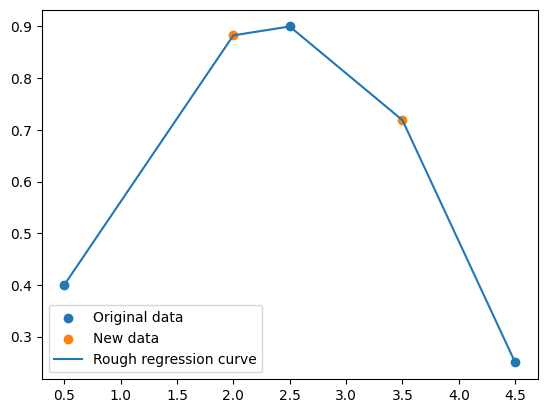

In [ ]:
# model sketch
plt.scatter(x, apply_weigths(x, w_ML), label="Original data")

x_new = np.array([2, 3.5])
plt.scatter(x_new, apply_weigths(x_new, w_ML), label="New data")

all_data = np.sort(np.hstack((x,x_new)))
plt.plot(all_data, apply_weigths(all_data, w_ML), label="Rough regression curve")
plt.legend()

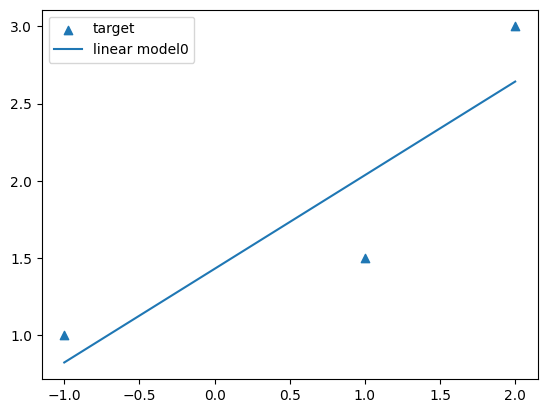

In [ ]:
# linear model
x = np.array([-1, 1, 2])[:, np.newaxis]
y = np.array([1, 1.5, 3])[:, np.newaxis]
N = len(x)
M = 2
bias = np.ones((N,1))
Phi = np.hstack((bias, x))
w_ML = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y


xspace = np.linspace(min(x), max(x))
plt.scatter(x, y, label="target", marker="^")
plt.plot(xspace, w_ML[0,0] + w_ML[1,0]*xspace, label="linear model0")
plt.legend()